In [ ]:
from scdeepsim.quality import rf_discriminability
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import StandardScaler
from scdesigner.simulators import NegBinCopula
from scdeepsim.ae import LightningAE
from scdeepsim.plot import compare_umap
from scdeepsim.quality import rf_discriminability, knn_discriminability
from scdeepsim.dataset import ScDataModule
from scdeepsim.lightning_diffusion import LightningDiffusion
from scdeepsim.vae import ZINBVAE as LightningVAE
import pytorch_lightning as pl
import anndata as ad 
import os

In [2]:
# Data reading and preprocessing
muris = sc.read_h5ad('../data/tabula_muris/all.h5ad')
np.random.seed(42)
# Data preprocessing and filtering: we keep a 10000x1000 subset of data
# Randomly pick 10000 cells and keep the 1000 most variable genes
muris.var_names_make_unique()
sc.pp.filter_cells(muris, min_genes=10)
sc.pp.filter_genes(muris, min_cells=2)

muris_10k =  muris[np.random.choice(muris.n_obs, 10000, replace=False)]
sc.pp.highly_variable_genes(muris_10k, flavor='seurat_v3', n_top_genes=2000)
muris_10k = muris_10k[:, muris_10k.var['highly_variable']]
muris_10k = muris_10k.copy()
muris_10k.X = muris_10k.X.toarray() # convert to dense matrix 
muris_10k.X

/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/scanpy/preprocessing/_highly_variable_genes.py:178: Trying to modify attribute `._uns` of view, initializing view as actual.


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(10000, 2000), dtype=float32)

In [ ]:
murisData = ScDataModule(muris_10k, "celltype", "LabelEncoder")
vae = LightningVAE(n_genes=muris_10k.X.shape[1], 
                   input_dropout=0.1)

trainer = pl.Trainer(
    max_epochs=100,
    accelerator="auto",
    devices="auto",
    log_every_n_steps=50,
    enable_checkpointing=True,
    logger=True,
    default_root_dir="lightning_logs/sim_bottleneck/vae"
)

vae_path = "checkpoints/sim_bottleneck/vae/trained_vae.ckpt"
if os.path.exists(vae_path):
    vae = LightningVAE.load_from_checkpoint(vae_path)
else:
    trainer.fit(vae, murisData)
    trainer.save_checkpoint(vae_path)

In [4]:
device = next(vae.parameters()).device
print(device)
X_tensor = torch.tensor(muris_10k.X, dtype=torch.float32, device=device)
vae.eval()
with torch.no_grad():
    X_encoded = vae.encode(X_tensor)
    real_lib_median = float(np.median(muris_10k.X.sum(axis=1)))
    prior_samples = vae.sample_from_prior(10000, target_library_size=real_lib_median).cpu().numpy().astype(int)
    latent_samples = vae.sample_from_latent(X_encoded[0], x_raw = X_tensor).cpu().numpy().astype(int)
    
print(knn_discriminability(prior_samples, muris_10k.X, 10))
print(knn_discriminability(latent_samples, muris_10k.X, 10))

cpu
(0.9982341069626639, 0.9935)
(0.9997477295660948, 0.9975)


In [14]:
with torch.no_grad():
    dec_mu, dec_theta, dec_pi_logit = vae.decode(X_encoded[0])
    dec_pi = torch.sigmoid(dec_pi_logit)

dec_mu_np = dec_mu.cpu().numpy()

# 如果 disc(dec_mu) << disc(latent_samples)：ZINB 采样本身引入了大量噪声
# 如果 disc(dec_mu) ≈ disc(latent_samples)：重建本身就是错的
print("dec_mu vs real:", knn_discriminability(dec_mu_np, muris_10k.X, n_neighbors=10))
print("latent_samples vs real:", knn_discriminability(latent_samples, muris_10k.X, n_neighbors=10))

dec_mu vs real: (0.997223624432105, 0.9835)
latent_samples vs real: (0.9985141158989599, 0.99175)


In [17]:
dec_mu_np.sum(axis=1)

array([460.85913, 714.6791 , 617.18384, ..., 503.9834 , 419.14307,
       871.47455], shape=(10000,), dtype=float32)

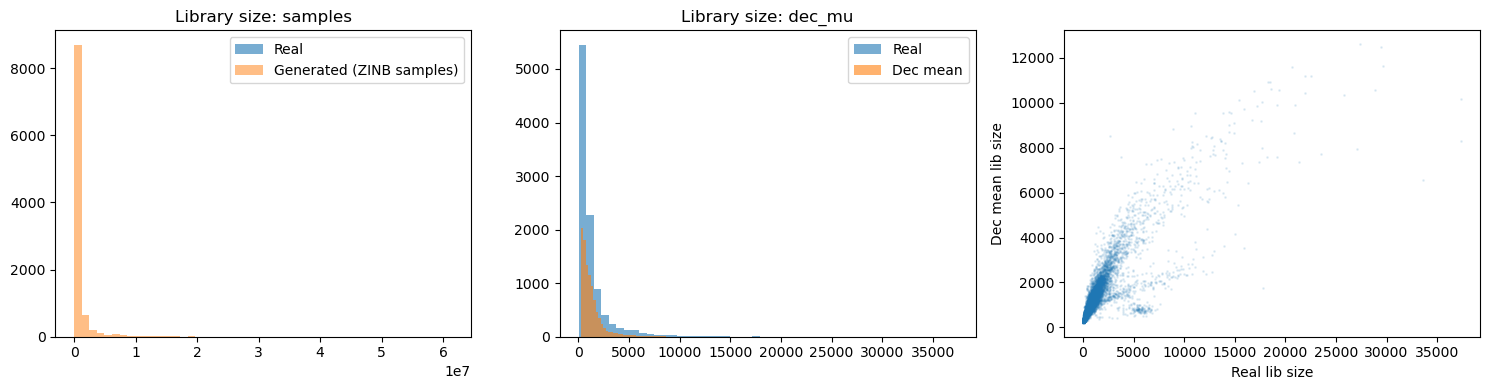

In [28]:
real_lib = muris_10k.X.sum(axis=1)
gen_lib_samples = latent_samples.sum(axis=1)
gen_lib_mean = dec_mu_np.sum(axis=1)   # decoderlibrary size

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(real_lib, bins=50, alpha=0.6, label='Real')
axes[0].hist(gen_lib_samples, bins=50, alpha=0.5, label='Generated (ZINB samples)')
axes[0].legend(); axes[0].set_title('Library size: samples')
axes[1].hist(real_lib, bins=50, alpha=0.6, label='Real')
axes[1].hist(gen_lib_mean, bins=50, alpha=0.6, label='Dec mean')
axes[1].legend(); axes[1].set_title('Library size: dec_mu')
axes[2].scatter(real_lib, gen_lib_mean[:len(real_lib)], alpha=0.1, s=1)
axes[2].set_xlabel('Real lib size'); axes[2].set_ylabel('Dec mean lib size')
plt.tight_layout(); plt.show()

Gene mean correlation (ZINB samples): -0.0432
Gene mean correlation (dec_mu):        0.6602


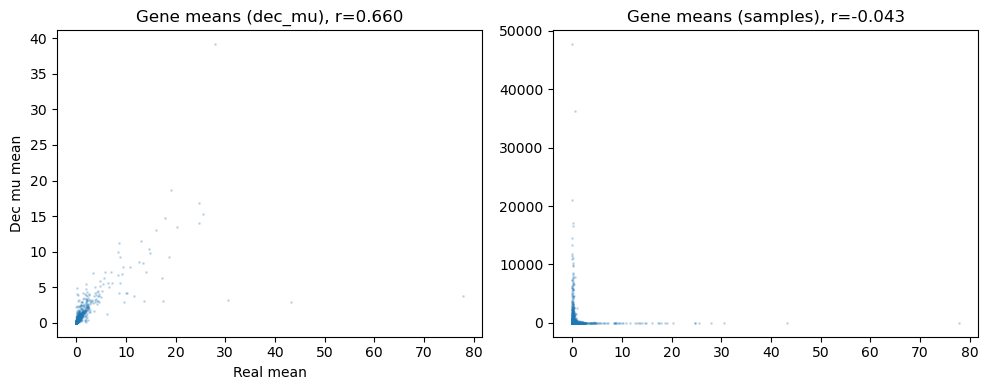

In [15]:
real_gene_means = muris_10k.X.mean(0)
gen_gene_means_samples = latent_samples.mean(0)
gen_gene_means_decmu = dec_mu_np.mean(0)

corr_samples = np.corrcoef(real_gene_means, gen_gene_means_samples)[0, 1]
corr_decmu = np.corrcoef(real_gene_means, gen_gene_means_decmu)[0, 1]
print(f"Gene mean correlation (ZINB samples): {corr_samples:.4f}")
print(f"Gene mean correlation (dec_mu):        {corr_decmu:.4f}")

# Scatter plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(real_gene_means, gen_gene_means_decmu, alpha=0.2, s=1)
axes[0].set_xlabel('Real mean'); axes[0].set_ylabel('Dec mu mean')
axes[0].set_title(f'Gene means (dec_mu), r={corr_decmu:.3f}')
axes[1].scatter(real_gene_means, gen_gene_means_samples, alpha=0.2, s=1)
axes[1].set_title(f'Gene means (samples), r={corr_samples:.3f}')
plt.tight_layout(); plt.show()

In [ ]:
encoded_muris_10k = ad.AnnData(X_encoded, obs=muris_10k.obs)
latent_dm = ScDataModule(encoded_muris_10k, "celltype", "LabelEncoder")
latent_dm.setup()

dim = encoded_muris_10k.X.shape[1]
num_classes = int(latent_dm.train_dataset.dataset.classes.max()) + 1

diffusion = LightningDiffusion(
    input_dim=dim,
    num_classes=num_classes,
    use_ema=True,
    ema_decay=0.999
    )

trainer = pl.Trainer(
    max_epochs=100,
    accelerator="auto",
    devices="auto",
    log_every_n_steps=50,
    enable_checkpointing=True,
    logger=True,
    default_root_dir="lightning_logs/sim_bottleneck/diffusion_with_vae"
)

diffusion_path = "checkpoints/sim_bottleneck/diffusion_with_vae/trained_diffusion_with_vae.ckpt"
if os.path.exists(diffusion_path):
    diffusion = LightningDiffusion.load_from_checkpoint(diffusion_path)
else:
    trainer.fit(diffusion, latent_dm)
    trainer.save_checkpoint(diffusion_path)

In [ ]:
# Fitting scdesigner simulator
nbc = NegBinCopula(mean_formula = "~ celltype")
nbc.fit(muris_10k, max_epochs=300, top_k=100)
nbc_samples = nbc.sample(obs=muris_10k.obs)


Estimating top-k copula covariance: 100%|██████████| 10/10 [00:02<00:00,  4.62it/s]


In [ ]:
cell_gene_auc, cell_gene_accuracy = knn_discriminability(nbc_samples.X, muris_10k.X, 10)
print("Discriminability by cells: ", cell_gene_auc, cell_gene_accuracy)

Discriminability by genes:  0.9066725510817308 0.82375
Discriminability by cells:  0.8993064688239747 0.778


In [ ]:


# NormalLog1p transformation
processed_muris_10k = muris_10k.copy()
sc.pp.normalize_total(processed_muris_10k, target_sum=10000)
sc.pp.log1p(processed_muris_10k)

murisData = ScDataModule(processed_muris_10k, "celltype", "LabelEncoder")
ae = LightningAE(n_genes=processed_muris_10k.X.shape[1], enc_hidden=[512, 512, 512])

trainer = pl.Trainer(
    max_epochs=100, # may need more training
    accelerator="auto",
    devices="auto",
    log_every_n_steps=50,
    enable_checkpointing=True,
    logger=True,
    default_root_dir="lightning_logs/sim_bottleneck/ae"
)

ae_path = "checkpoints/sim_bottleneck/ae/trained_ae_smaller.ckpt"
if os.path.exists(ae_path):
    ae = LightningAE.load_from_checkpoint(ae_path)
else:
    trainer.fit(ae, murisData)
    trainer.save_checkpoint(ae_path)

device = next(ae.parameters()).device
X_tensor = torch.tensor(processed_muris_10k.X, dtype=torch.float32, device=device)
ae.eval()
with torch.no_grad():
    X_encoded = ae.encode(X_tensor).cpu().numpy()
    
standard_scaler = StandardScaler()
X_encoded = standard_scaler.fit_transform(X_encoded)
encoded_muris_10k = ad.AnnData(X_encoded, obs=muris_10k.obs)
latent_dm = ScDataModule(encoded_muris_10k, "celltype", "LabelEncoder")
latent_dm.setup()

dim = encoded_muris_10k.X.shape[1]
num_classes = int(latent_dm.train_dataset.dataset.classes.max()) + 1


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [8]:
# Training diffusion model
diffusion = LightningDiffusion(
    input_dim=dim,
    num_classes=num_classes,
    use_ema=True,
    ema_decay=0.999
    )

trainer = pl.Trainer(
    max_epochs=100,
    accelerator="auto",
    devices="auto",
    log_every_n_steps=50,
    enable_checkpointing=True,
    logger=True,
    default_root_dir="lightning_logs/sim_bottleneck/diffusion"
)

diffusion_path = "checkpoints/sim_bottleneck/diffusion/trained_diffusion.ckpt"
if os.path.exists(diffusion_path):
    diffusion = LightningDiffusion.load_from_checkpoint(diffusion_path)
else:
    trainer.fit(diffusion, latent_dm)
    trainer.save_checkpoint(diffusion_path)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Performing UMAP on combined dataset (20000 samples, 128 features) across 2 datasets...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


([array([[ 5.485276  ,  6.6534476 ],
         [ 3.0871398 ,  9.489666  ],
         [ 0.64394265,  7.446224  ],
         ...,
         [-2.0499966 ,  3.8856897 ],
         [ 0.39485788,  3.2296574 ],
         [ 2.2251256 ,  5.892525  ]], shape=(10000, 2), dtype=float32),
  array([[-1.2380835 , 12.905461  ],
         [ 0.27593747,  4.6319385 ],
         [-0.3262544 ,  6.4847007 ],
         ...,
         [ 0.5771083 ,  2.9255192 ],
         [ 4.270566  ,  4.2444997 ],
         [ 1.5707222 ,  7.7847147 ]], shape=(10000, 2), dtype=float32)],
 <Figure size 1400x600 with 2 Axes>)

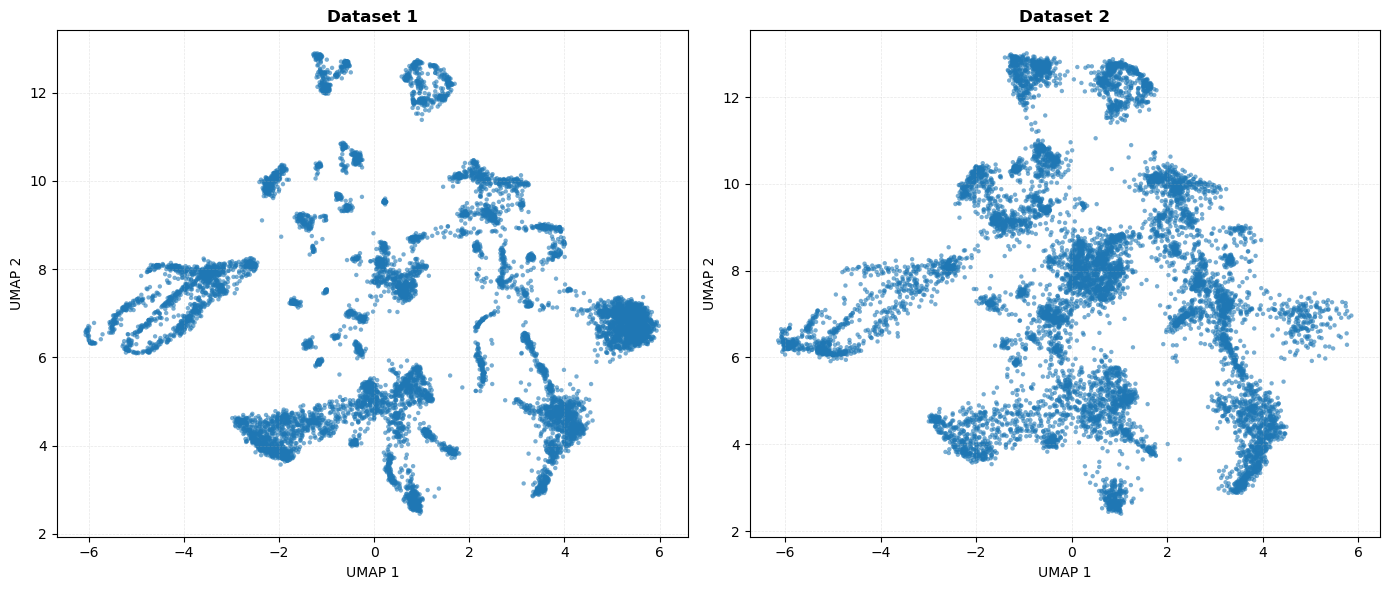

In [9]:
# sampling from diffusion model

if not os.path.exists("samples/latent_samples.npy"):
    diffusion.eval()
    with torch.no_grad():
        latent_samples = diffusion.sample(num_samples=10000,
                                        sampling_timesteps=diffusion.diffusion.num_timesteps,
                                        ddim_sampling_eta=0.0,
                                        use_ema=True,
                                        clip_denoised=False, 
                                        )
    latent_samples = latent_samples.cpu().numpy() 
    np.save("samples/latent_samples.npy", latent_samples)
else:
    latent_samples = np.load("samples/latent_samples.npy")
    
compare_umap([X_encoded, latent_samples])

In [9]:
knn_discriminability(X_encoded, latent_samples, 10)

(0.6702180376610506, 0.56525)

In [11]:
it_latent_samples = standard_scaler.inverse_transform(latent_samples)
it_latent_samples = torch.tensor(it_latent_samples).to(device=device, dtype=torch.float32)
with torch.no_grad():
    decoded_samples = ae.decode(it_latent_samples).cpu().numpy()

In [11]:
knn_discriminability(processed_muris_10k.X, decoded_samples, 10)

(0.8803270564915758, 0.77475)

Performing UMAP on combined dataset (20000 samples, 2000 features) across 2 datasets...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


([array([[-2.9149985,  4.107835 ],
         [-1.9366044,  5.675814 ],
         [-1.9118687, 11.648741 ],
         ...,
         [ 1.3721986, 11.864146 ],
         [ 1.9533039,  7.468594 ],
         [-1.8607854,  4.3313327]], shape=(10000, 2), dtype=float32),
  array([[ 1.3275608 , 11.848025  ],
         [-4.7035813 ,  8.316221  ],
         [-0.24482493,  9.057438  ],
         ...,
         [-0.3196652 ,  8.511394  ],
         [-4.538235  ,  7.428809  ],
         [-0.94511014, 11.213704  ]], shape=(10000, 2), dtype=float32)],
 <Figure size 1400x600 with 2 Axes>)

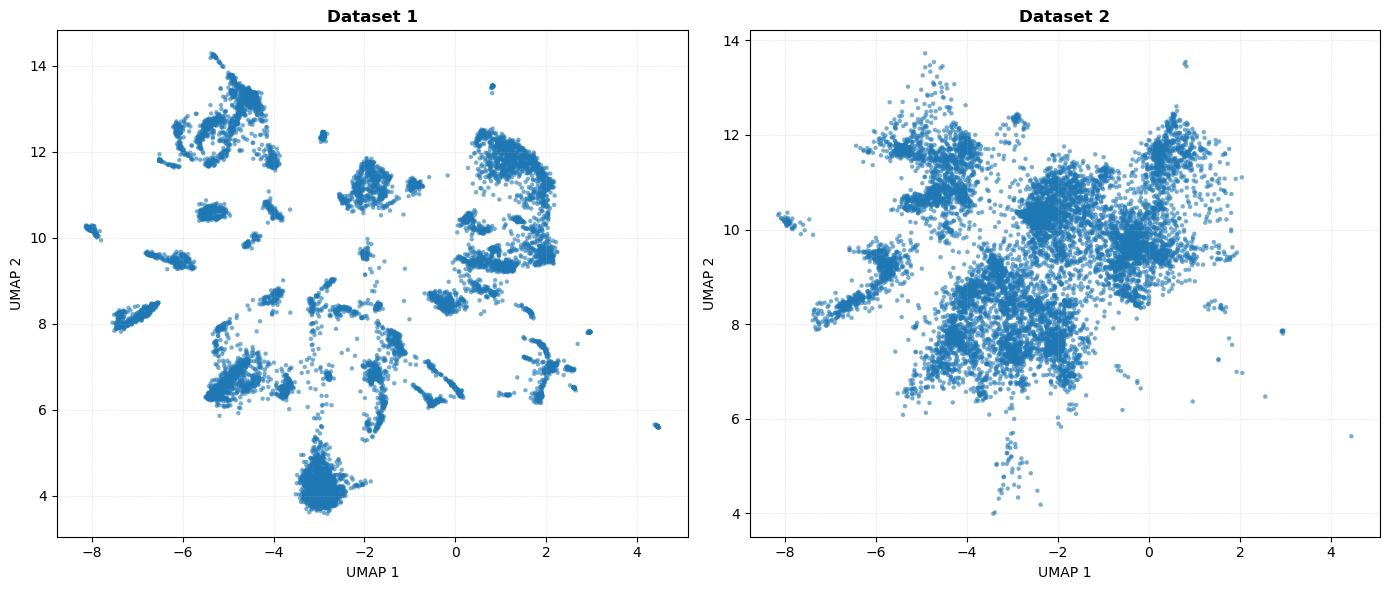

In [12]:
compare_umap([processed_muris_10k.X, decoded_samples])

Performing UMAP on combined dataset (20000 samples, 2000 features) across 2 datasets...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


([array([[ 8.072196 , 12.182669 ],
         [ 7.553624 ,  9.404421 ],
         [17.824612 ,  0.0294403],
         ...,
         [19.739443 ,  7.6769085],
         [14.477307 , 10.958372 ],
         [11.850659 , 10.3035755]], shape=(10000, 2), dtype=float32),
  array([[ 8.074021, 11.645884],
         [ 8.482871, 11.686   ],
         [16.428299, 12.059643],
         ...,
         [18.205652,  8.440801],
         [14.30262 , 11.133083],
         [12.51097 , 10.046481]], shape=(10000, 2), dtype=float32)],
 <Figure size 1400x600 with 2 Axes>)

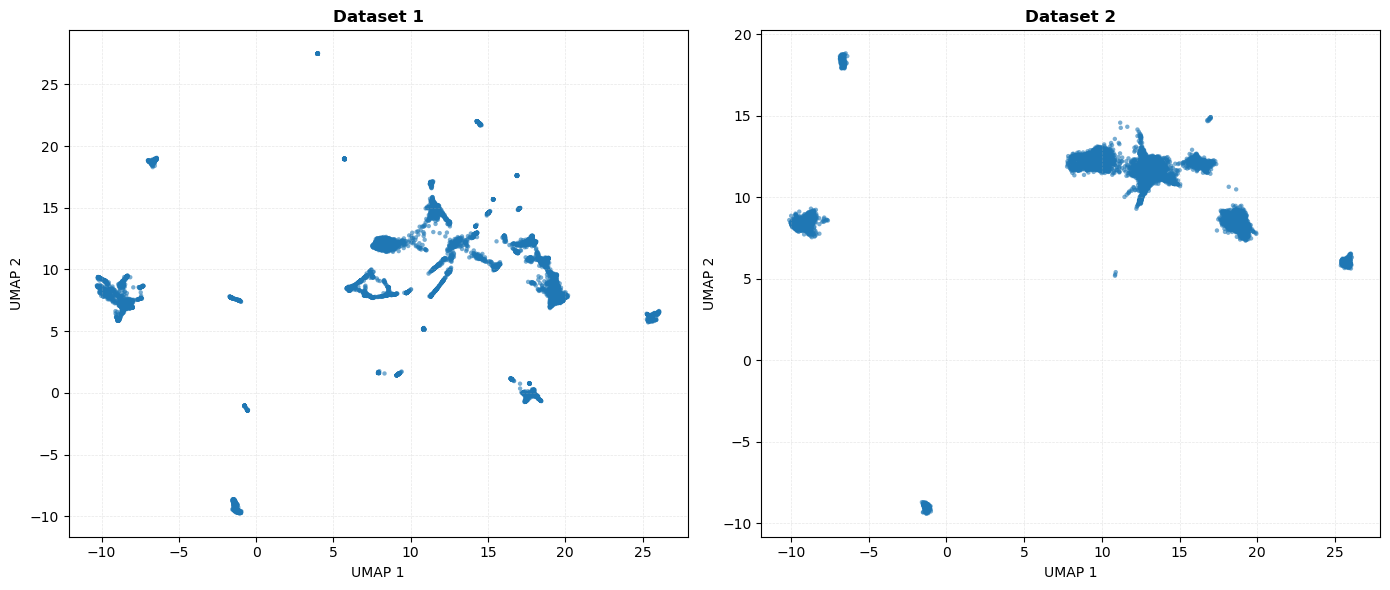

In [12]:
processed_nbc_samples = nbc_samples.copy()
sc.pp.normalize_total(processed_nbc_samples, target_sum=10000)
sc.pp.log1p(processed_nbc_samples)
compare_umap([processed_muris_10k.X, processed_nbc_samples.X])

Performing UMAP on combined dataset (30000 samples, 2000 features) across 3 datasets...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


([array([[ 8.182215 , 11.297062 ],
         [ 7.136764 , 18.63593  ],
         [ 6.1530585, 23.10559  ],
         ...,
         [ 9.267632 , 19.694086 ],
         [ 8.778089 , 14.866206 ],
         [ 6.502937 , 14.290041 ]], shape=(10000, 2), dtype=float32),
  array([[ 9.151866 , 19.902952 ],
         [ 5.389375 , 22.092821 ],
         [ 7.8376517, 22.8305   ],
         ...,
         [ 7.814439 , 22.831448 ],
         [ 5.120732 , 18.960903 ],
         [ 6.929432 , 23.08916  ]], shape=(10000, 2), dtype=float32),
  array([[ 8.04165  , 11.078512 ],
         [ 8.002652 , 11.512607 ],
         [ 9.51193  , 16.05864  ],
         ...,
         [ 9.875137 , 18.348879 ],
         [ 8.58258  , 14.847644 ],
         [ 6.4653115, 14.8080635]], shape=(10000, 2), dtype=float32)],
 <Figure size 2100x600 with 3 Axes>)

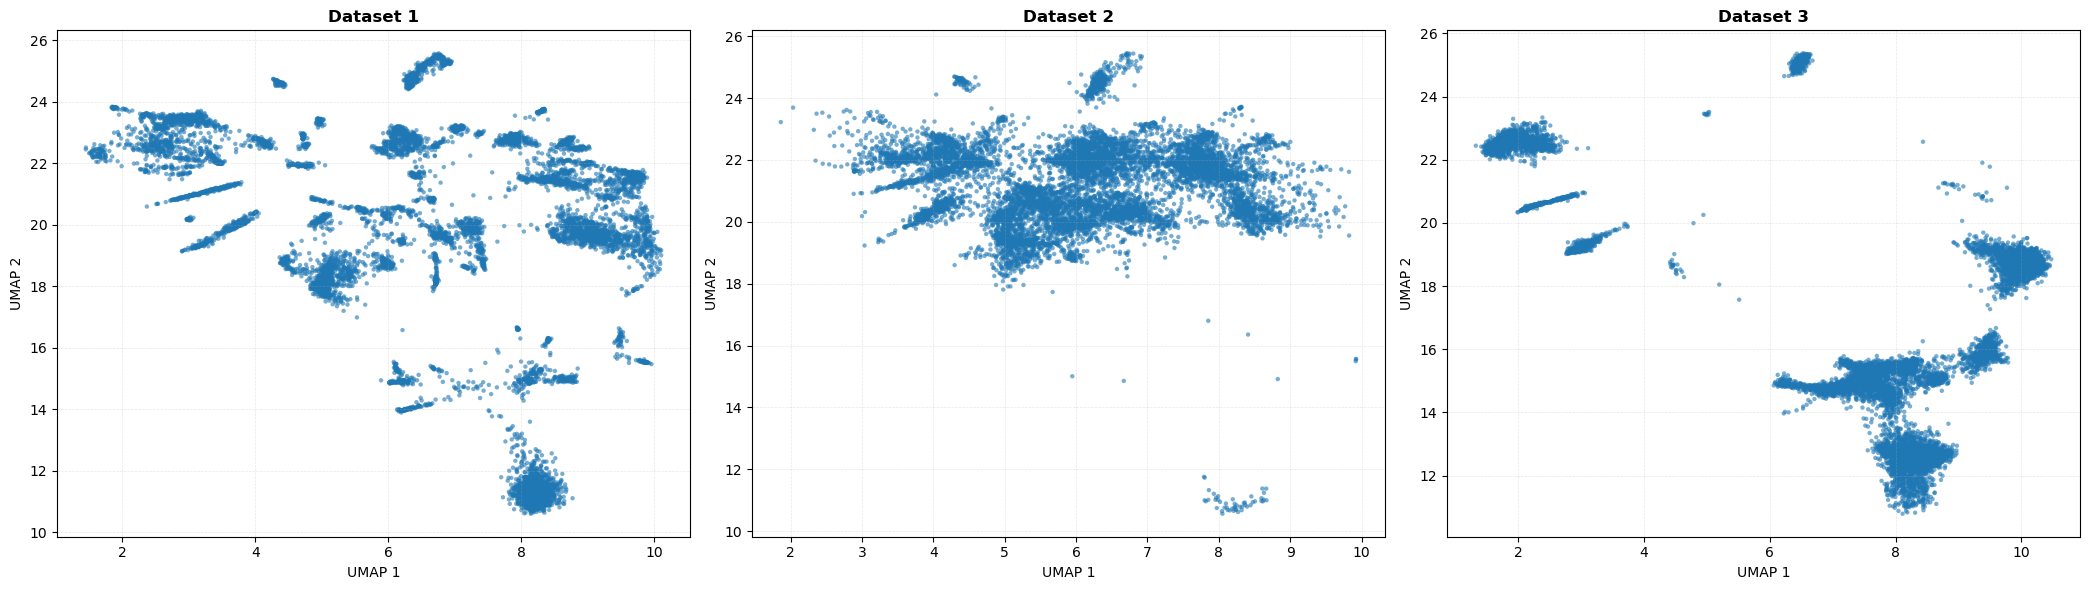

In [13]:
compare_umap([processed_muris_10k.X, decoded_samples, processed_nbc_samples.X])

Performing UMAP on combined dataset (30000 samples, 128 features) across 3 datasets...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


([array([[-12.425817,  13.285167],
         [-12.861854,  17.51729 ],
         [-12.757104,  20.621502],
         ...,
         [ -9.471959,  19.43475 ],
         [ -7.600432,  16.073027],
         [ -8.70617 ,  12.351176]], shape=(10000, 2), dtype=float32),
  array([[ -9.43487 ,  18.15337 ],
         [ -9.812774,  20.627934],
         [-10.769109,  20.448952],
         ...,
         [ -6.95644 ,  16.521717],
         [-14.287065,  14.912678],
         [-13.607   ,  17.536814]], shape=(10000, 2), dtype=float32),
  array([[-12.052814,  13.17886 ],
         [-12.553225,  13.245569],
         [ -8.766347,  16.840347],
         ...,
         [ -9.463159,  17.818724],
         [ -8.589508,  15.147671],
         [ -9.45547 ,  14.102355]], shape=(10000, 2), dtype=float32)],
 <Figure size 2100x600 with 3 Axes>)

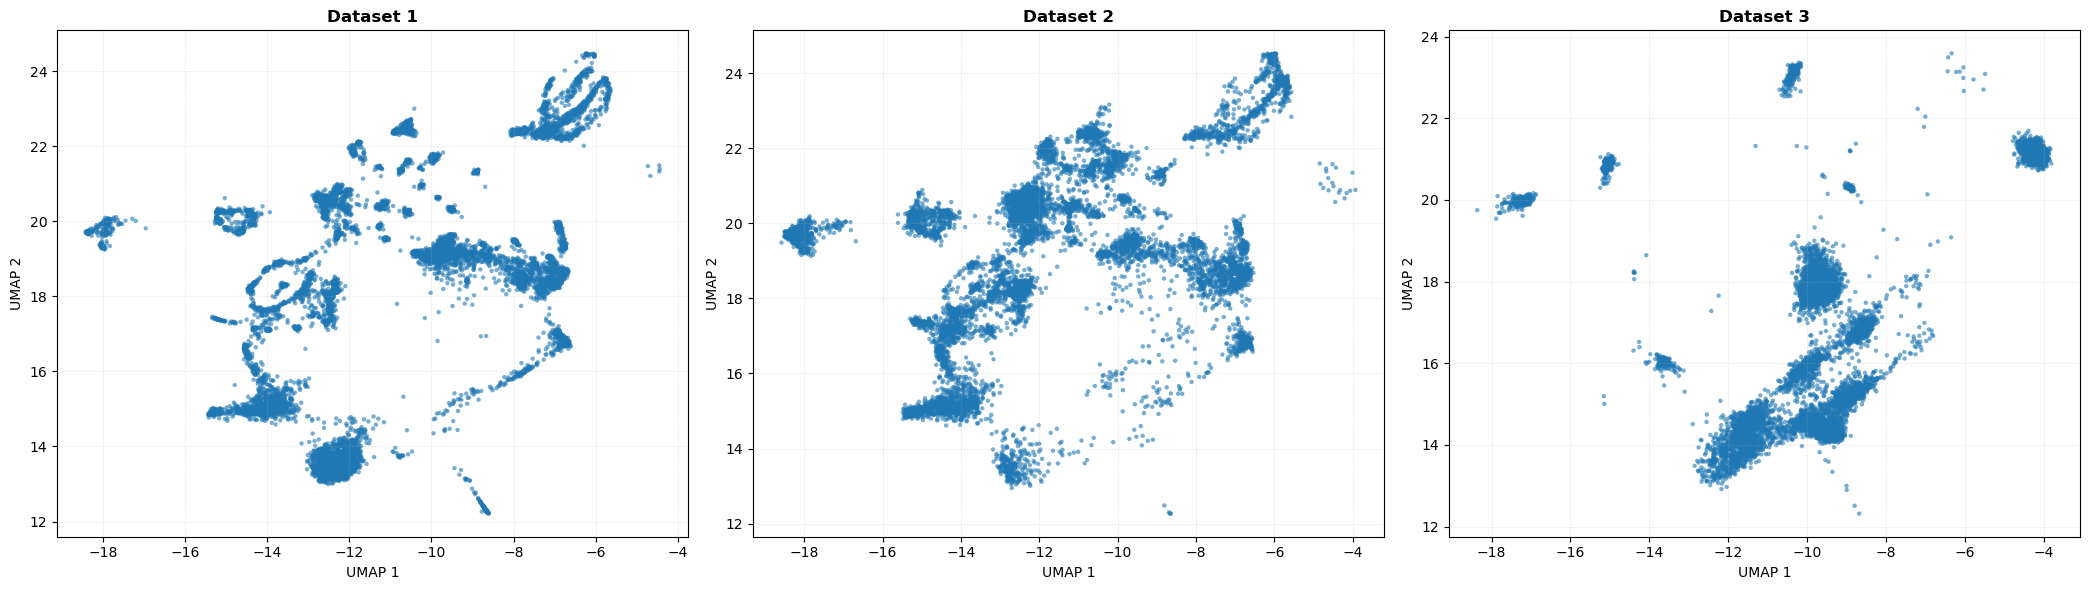

In [14]:
with torch.no_grad():
    encoded_nbc_samples = ae.encode(torch.tensor(processed_nbc_samples.X, 
                                             dtype=torch.float32, device=device))
encoded_nbc_samples = standard_scaler.transform(encoded_nbc_samples)
compare_umap([X_encoded,latent_samples, encoded_nbc_samples]) 

In [15]:
knn_discriminability(X_encoded, encoded_nbc_samples, 10)

(0.9874389825575871, 0.9435)